# Hovmoller FWC and SIC distribution

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46867")
client

<Client: 'tcp://127.0.0.1:46867' processes=8 threads=32, memory=123.95 GiB>

**PROCEDURE:**

1. Select days after sea ice minimum each year.
2. Mask grid cells where SIC>15% at minimum.
3. Calculate FWC in each grid cell, then bin grid cells (e.g., 0.1 m increments).
4. For each FWC bin and timestep, compute percent grid cells >15% SIC or compute mean SIC.

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## Plot SIC time series in Beaufort box

In [8]:
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [9]:
ice_select = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))*beaufort_area

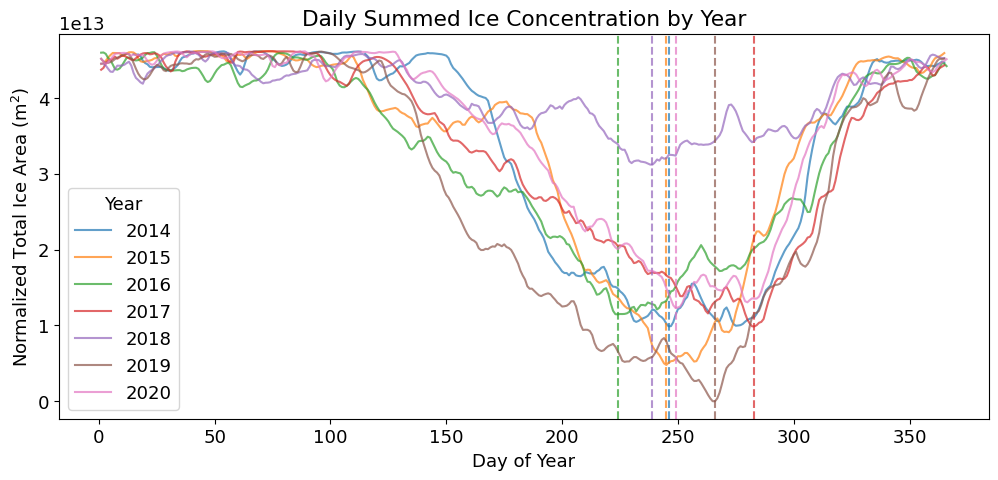

In [10]:
plt.rcParams['font.size'] = 13

# Sum over spatial dimensions (i, j) for daily total ice concentration
daily_ice_sum = ice_select.sum(dim=['i', 'j'])
daily_ice_sum = daily_ice_sum.where(daily_ice_sum != 0)
daily_ice_sum = daily_ice_sum - daily_ice_sum.min() # normalize

# Group by year
grouped = daily_ice_sum.groupby("time.year")

# Plot
plt.figure(figsize=(12, 5))

for year, data in grouped:
    doy = data['time'].dt.dayofyear  # Day of year
    line, = plt.plot(doy, data, label=str(year), alpha=0.7)  # Plot time series

    # Find the day of the minimum value for the year
    min_day = doy[data.argmin().values]
    
    # Plot vertical line with the same color as the corresponding time series
    plt.axvline(min_day, color=line.get_color(), linestyle='--', alpha=0.7)

plt.xlabel('Day of Year')
plt.ylabel('Normalized Total Ice Area (m$^2$)')
plt.title('Daily Summed Ice Concentration by Year')
plt.legend(title='Year')
plt.show()

Extent counts all grid cells ≥15% ice concentration

In [11]:
ice_select = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))

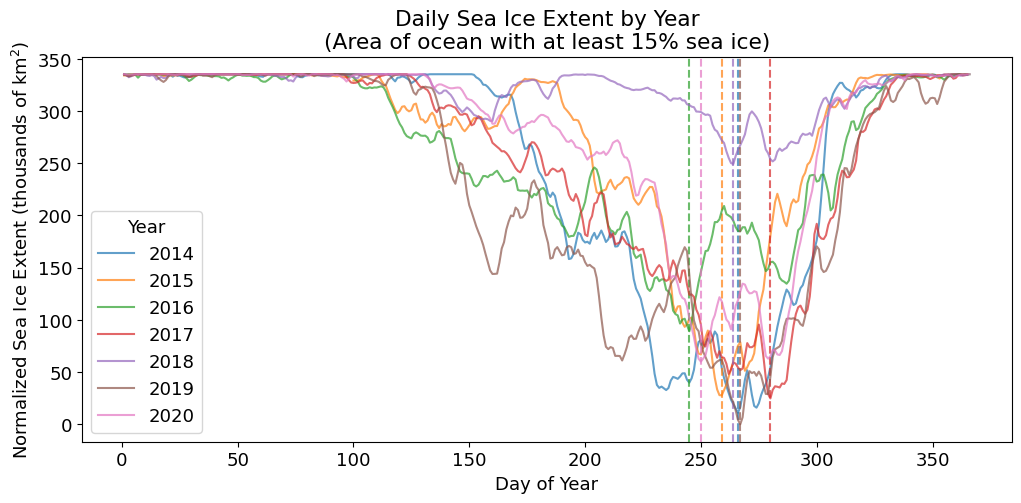

In [12]:
plt.rcParams['font.size'] = 13

# count grid cells where ice concentration >= 15% and sum their areas
ice_area_extent = ((ice_select >= 15) * beaufort_area).sum(dim=['i', 'j'])

# mask zero values for visualization clarity
ice_area_extent = ice_area_extent.where(ice_area_extent != 0)

# normalize
ice_extent = ice_area_extent - ice_area_extent.min()

# group by year
grouped = ice_extent.groupby("time.year")

# plot
plt.figure(figsize=(12, 5))

for year, data in grouped:
    doy = data['time'].dt.dayofyear  # Day of year
    line, = plt.plot(doy, data/1e9, label=str(year), alpha=0.7)  # Plot time series

    # Find the day of the minimum extent for the year
    min_day = doy[data.argmin().values]

    # Plot vertical line at the minimum extent
    plt.axvline(min_day, color=line.get_color(), linestyle='--', alpha=0.7)

plt.xlabel('Day of Year')
plt.ylabel('Normalized Sea Ice Extent (thousands of km$^2$)')
plt.title('Daily Sea Ice Extent by Year\n(Area of ocean with at least 15% sea ice)')
plt.legend(title='Year')
plt.show()

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [11]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
ice_area_beaufort = ice_beaufort*beaufort_area

In [12]:
# # calculating minimum based on total area (SIC per grid cell * grid cell area)
# # sum over spatial dimensions (i, j) for daily total ice concentration
# daily_ice_sum = ice_area_beaufort.sum(dim=['i', 'j'])
# daily_ice_sum = daily_ice_sum.where(daily_ice_sum != 0)

# # group by year
# grouped = daily_ice_sum.groupby("time.year")

# # find the day of the minimum value for the year
# min_day = []
# for year, data in grouped:
#     sic_min_yr = data['time']
#     min_day_tmp = sic_min_yr[data.argmin().values].values
#     min_day.append(min_day_tmp)
#     print(min_day_tmp)

2014-09-03T12:00:00.000000000
2015-09-02T12:00:00.000000000
2016-08-11T12:00:00.000000000
2017-10-10T12:00:00.000000000
2018-08-27T12:00:00.000000000
2019-09-23T12:00:00.000000000
2020-09-05T12:00:00.000000000


In [102]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_day = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_day.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [103]:
# select days after sea ice minimum for SIC and salinity

# start with first year (2014)
ice_yr = ice_beaufort.sel(time=slice(min_day[0],str(min_day[0])[0:4]+'-12-31'))
salt_yr = salt_beaufort.sel(time=slice(min_day[0],str(min_day[0])[0:4]+'-12-31')).isel(k=slice(0,8)) # only upper 12 m

In [104]:
# create mask for SIC>15% on annual sea ice minimum and land grid cells
land_sic_mask_yr = (ice_yr.isel(time=0)<15) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)

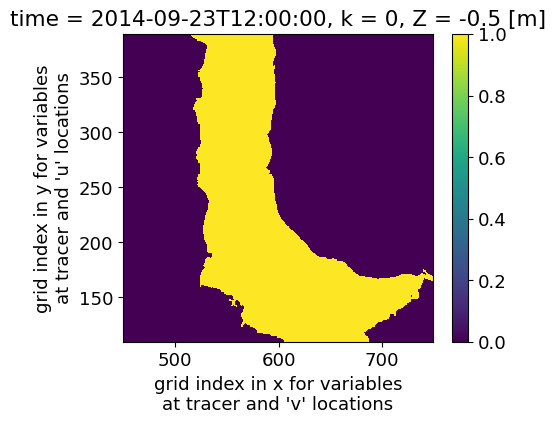

In [105]:
land_sic_mask_yr.plot(figsize=[5,4]);

## 2. Calculate FWC and bin data into 100 bins

In [106]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [107]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8))
fwc_beaufort_yr = calculate_fwc(salt_yr, salt_ref, dz)

In [108]:
# mask land grid cells and where SIC>15% on ice minimum date
ice_yr_masked = ice_yr.where(land_sic_mask_yr)
fwc_yr_masked = fwc_beaufort_yr.where(land_sic_mask_yr)

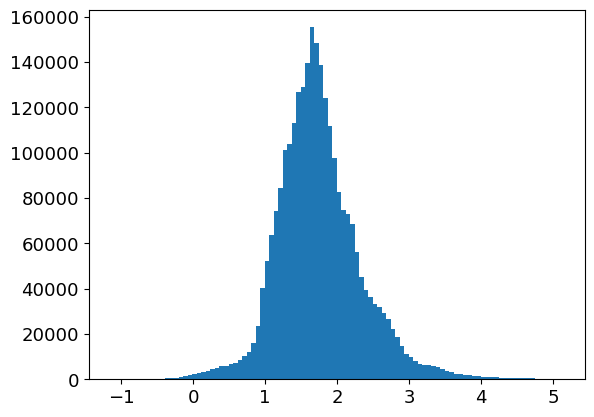

In [109]:
plt.hist(np.ravel(fwc_yr_masked.values),100);

In [110]:
# define FWC bins
fwc_bins = np.linspace(0,5,99)
fwc_bins = np.append(fwc_bins, 8) # total of 100

In [111]:
len(fwc_bins)

100

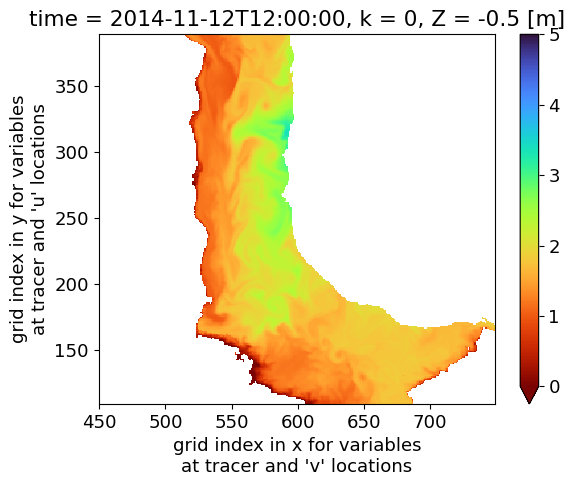

In [115]:
fwc_yr_masked.isel(time=50).plot(vmin=0,vmax=5,cmap='turbo_r');

In [116]:
# bin each grid cell into FWC intervals
# use np.digitize to bin the values according to fwc_bins
fwc_binned_yr = np.digitize(fwc_yr_masked, fwc_bins, right=False)

In [117]:
fwc_binned_yr.shape

(100, 280, 300)

In [119]:
# sanity check
print(fwc_binned_yr[0,110,145]) # index = 92
print(fwc_bins[92])
print(fwc_bins[91:93])
print(fwc_yr_masked.values[0,110,145]) # looks good

92
4.6938775510204085
[4.64285714 4.69387755]
4.676286357243855


In [120]:
fwc_binned_da = xr.DataArray(data = fwc_binned_yr, dims=['time', 'j', 'i'],\
                             coords={'time': fwc_yr_masked.time.values, 'j': fwc_yr_masked.j.values, 'i': fwc_yr_masked.i.values})

In [121]:
# mask out land and sea ice
fwc_binned_da = fwc_binned_da.where(land_sic_mask_yr)

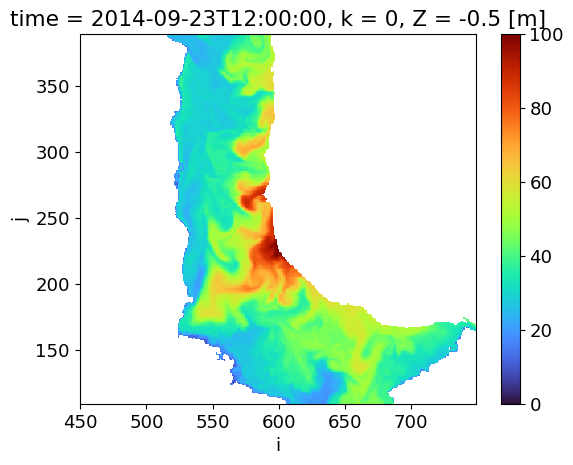

In [124]:
fwc_binned_da.isel(time=0).plot(vmin=0,vmax=100,cmap='turbo');

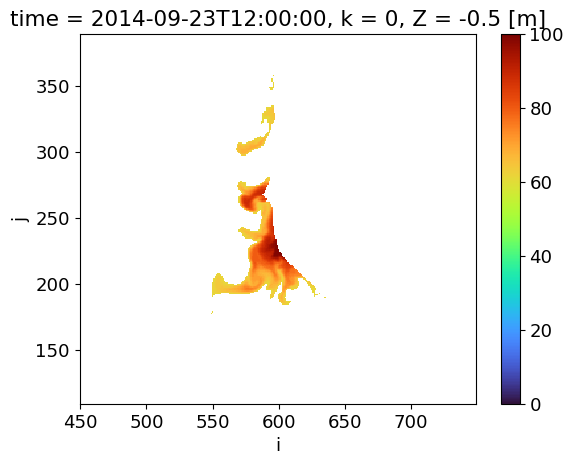

In [126]:
fwc_binned_da.isel(time=0).where((fwc_binned_da.isel(time=0)>60) & (fwc_binned_da.isel(time=0)<100)).plot(vmin=0,vmax=100,cmap='turbo');

In [127]:
ice_yr_masked.shape

(100, 280, 300)

In [128]:
fwc_binned_da.shape

(100, 280, 300)

## 3a. Group by bins and calculate mean SIC for each bin for every time step

In [129]:
# group by bins and calculate % grid cells over 15%
ice_grouped_mean = ice_yr_masked.groupby(fwc_binned_da).mean(dim=['i','j'])

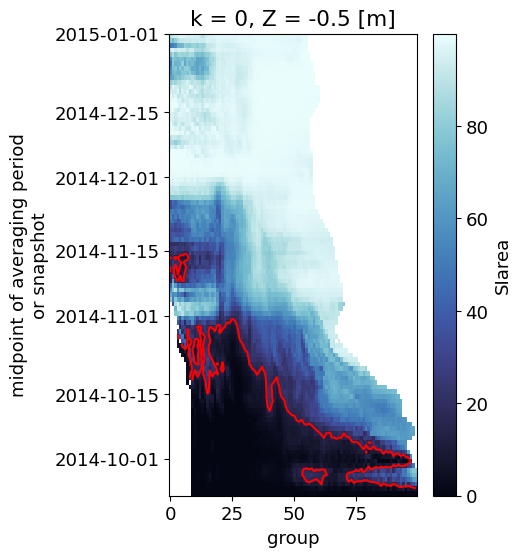

In [144]:
ice_grouped_mean.plot(y='time',x='group',figsize=[4,6],cmap=cmocean.cm.ice);
ice_grouped_mean.plot.contour(y='time',x='group',levels=[15],colors='r');

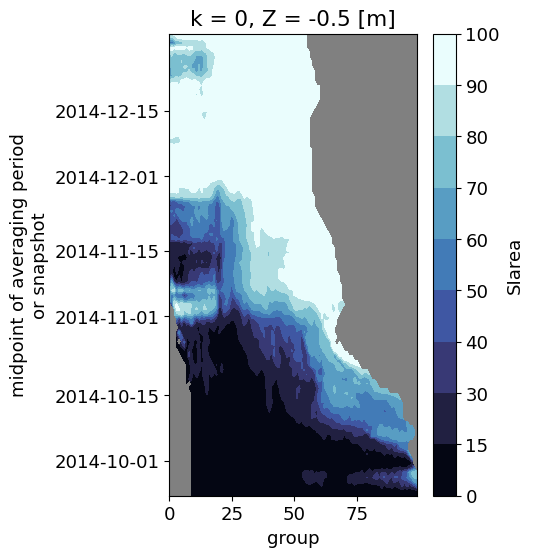

In [136]:
fig, ax = plt.subplots(1,1,figsize=[4,6])
ice_grouped_mean.plot.contourf(ax=ax,y='time',x='group',levels=[0,15,30,40,50,60,70,80,90,100],cmap=cmocean.cm.ice);
ax.set_facecolor('gray')

## 3b. Group by bins and calculate percentage of grid cells where SIC>15% for each FWC bin

In [137]:
# threshold for sea ice concentration
threshold = 15  # Percent

# convert to a binary mask where sea ice concentration > 15%
ice_binary = (ice_yr_masked > threshold).astype(int)

In [138]:
# count the number of cells above threshold per bin
count_above_threshold = ice_binary.groupby(fwc_binned_da).sum(dim=["i", "j"])

# count total number of grid cells in each bin
total_count_per_bin = fwc_binned_da.groupby(fwc_binned_da).count(dim=["i", "j"])

# compute percentage of grid cells > 15% sea ice concentration
percent_above_threshold = (count_above_threshold / total_count_per_bin) * 100

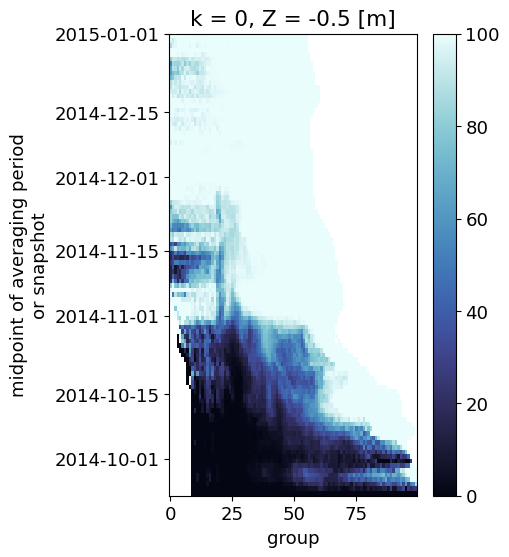

In [139]:
percent_above_threshold.plot(y='time',x='group',figsize=[4,6],cmap=cmocean.cm.ice);

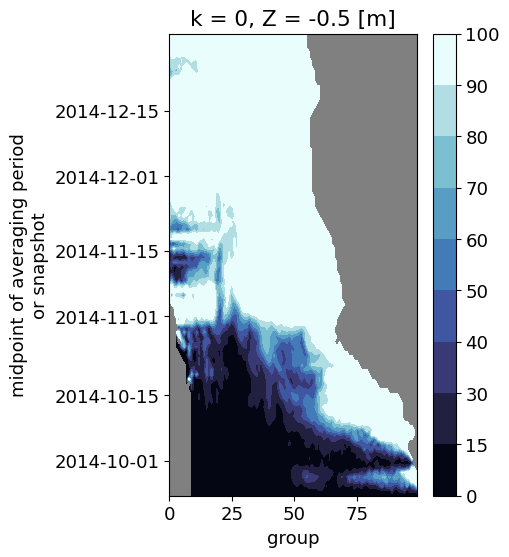

In [140]:
fig, ax = plt.subplots(1,1,figsize=[4,6])
percent_above_threshold.plot.contourf(ax=ax,y='time',x='group',levels=[0,15,30,40,50,60,70,80,90,100],cmap=cmocean.cm.ice);
ax.set_facecolor('gray')